# Bank Customer Churn Analysis

## 1. Introduction

The main goal of this project was to identify and visualise which factors 
contribute to customer churn in a European bank, enabling data-driven decisions 
to reduce churn rates and design targeted retention strategies for the most 
at-risk customer segments.

**Dataset:** Bank Customer Churn Prediction — 10,000 records, 14 columns. 
Source: Kaggle.

**Tools used:**
- **Python** — core programming language
- **Pandas** — data cleaning and manipulation
- **Matplotlib & Seaborn** — data visualisation
- **SQL (PostgreSQL)** — exploratory analysis and pattern discovery

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the dataframe
df_churn = pd.read_csv('../data/Churn_Modelling.csv')
df_churn.shape

(10000, 14)

## 2. Data Overview

The dataset contains 10,000 rows and 14 columns. Before analysis, three 
irrelevant columns were removed: `RowNumber`, `CustomerId`, and `Surname`.

**Categorical columns:** Geography, Gender, NumOfProducts, HasCrCard, 
IsActiveMember

**Continuous columns:** CreditScore, Age, Tenure, Balance, EstimatedSalary

**Target variable:** `Exited` — indicates whether a customer churned (1) 
or was retained (0).

No missing values were found across any column, requiring no imputation 
or data filling.

To improve chart readability, a new column `Exited_Label` was created, 
mapping the binary values to descriptive labels: `0 → Retained` 
and `1 → Churned`.

In [204]:
# Checking for missing values
df_churn.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [205]:
# Getting unique values counts
df_churn.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [206]:
# Dropping columns that don't matter for the analysis
df_churn = df_churn.drop(columns=['RowNumber','CustomerId','Surname'])

In [207]:
# For easier visualization in the charts, I'll add a column to call 0 and 1 for 'Exited' by what they really mean
df_churn['Exited_Label'] = df_churn['Exited'].map({0: 'Retained', 1: 'Churned'})
display(df_churn)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Exited_Label
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Churned
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Retained
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Churned
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Retained
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Retained
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Retained
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Retained
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,Churned
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Churned


In [208]:
# Checking important information 
display(df_churn.describe())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Visual Analysis

The following charts explore the relationship between customer attributes 
and churn behaviour. The overall churn rate is displayed as a pie chart 
for a quick proportion overview. Categorical variables are visualised 
using countplots to compare churned vs retained customers across each 
group. Continuous variables such as Balance, Tenure, CreditScore and EstimatedSalary
are displayed as boxplots, which reveal distributional differences and 
risk ranges between churned and retained customers.

### 3.1 Overall Churn Rate

The following chart represents the bank's overall churn rate, independent 
of any customer attributes. This gives us a baseline to compare against 
when analysing specific segments.

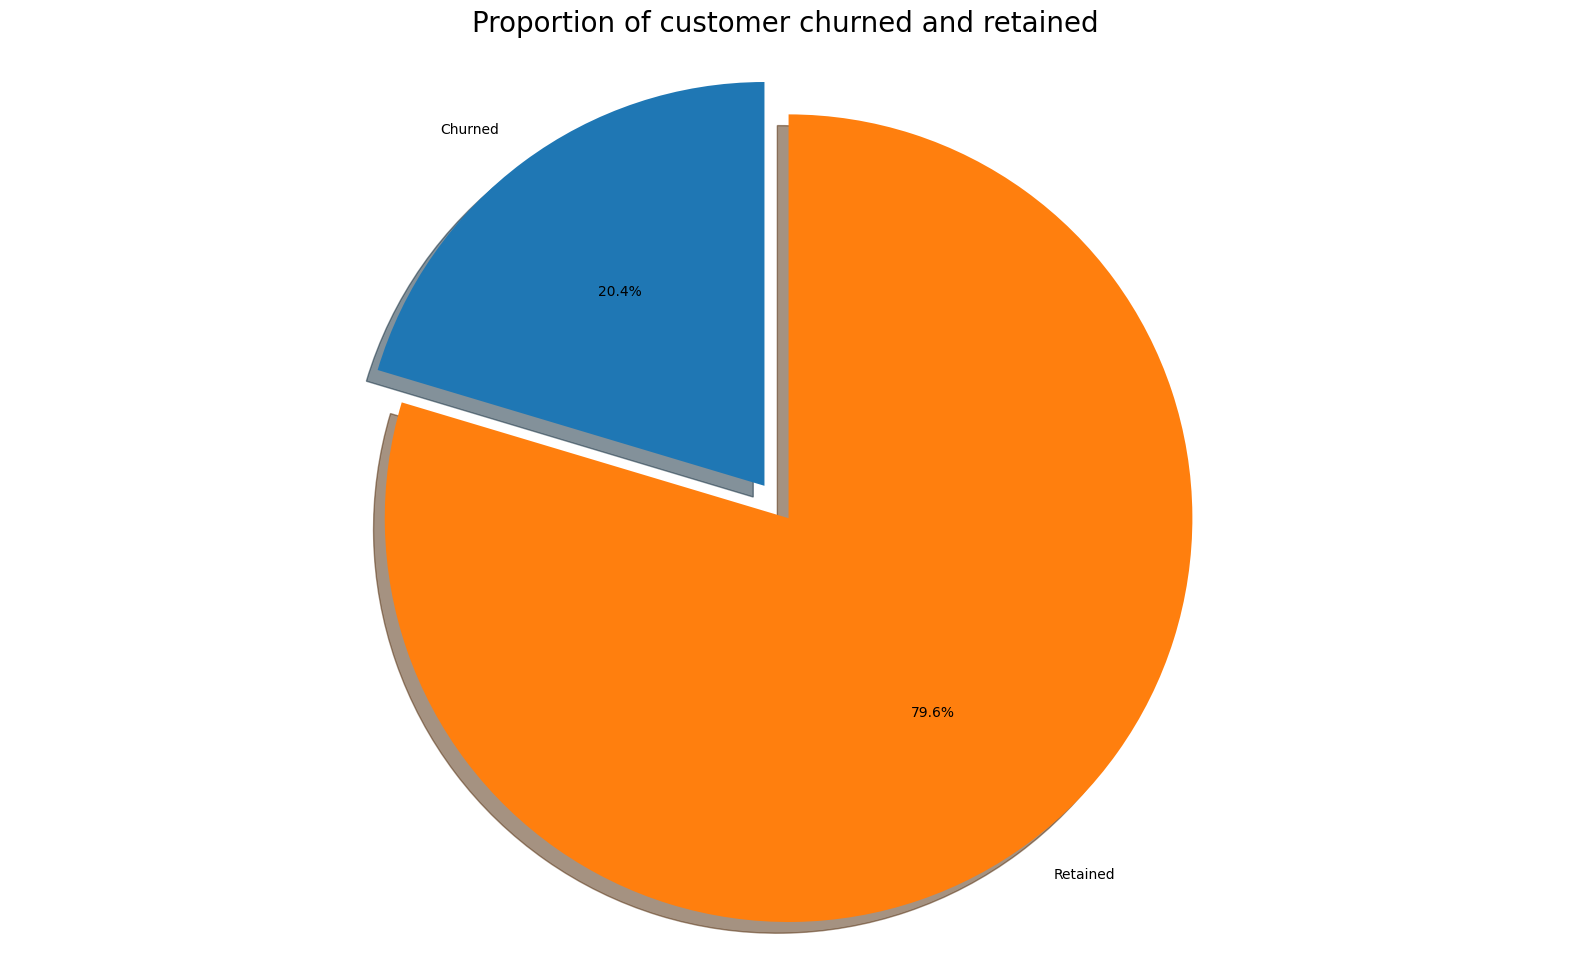

In [209]:
labels = 'Churned', 'Retained'
sizes = [df_churn.Exited[df_churn['Exited']==1].count(), df_churn.Exited[df_churn['Exited']==0].count()]
explode = (0, 0.1)
fig1, ax1 = plt.subplots(figsize=(20, 12))
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')
plt.title("Proportion of customer churned and retained", size = 20)
plt.show()

The overall churn rate stands at **20.4%**. Industry benchmarks suggest 
that a healthy churn rate for retail banks sits below 15%, making this 
figure a clear red flag. This baseline will serve as a reference point 
throughout the analysis — any segment exceeding 20.4% represents an 
above-average risk group requiring targeted attention.

### 3.2 Categorical Variable Analysis

The following countplots display the relationship between categorical 
variables and customer churn. Each chart compares the number of churned 
vs retained customers across different groups, making it easy to spot 
which segments carry the highest churn risk.

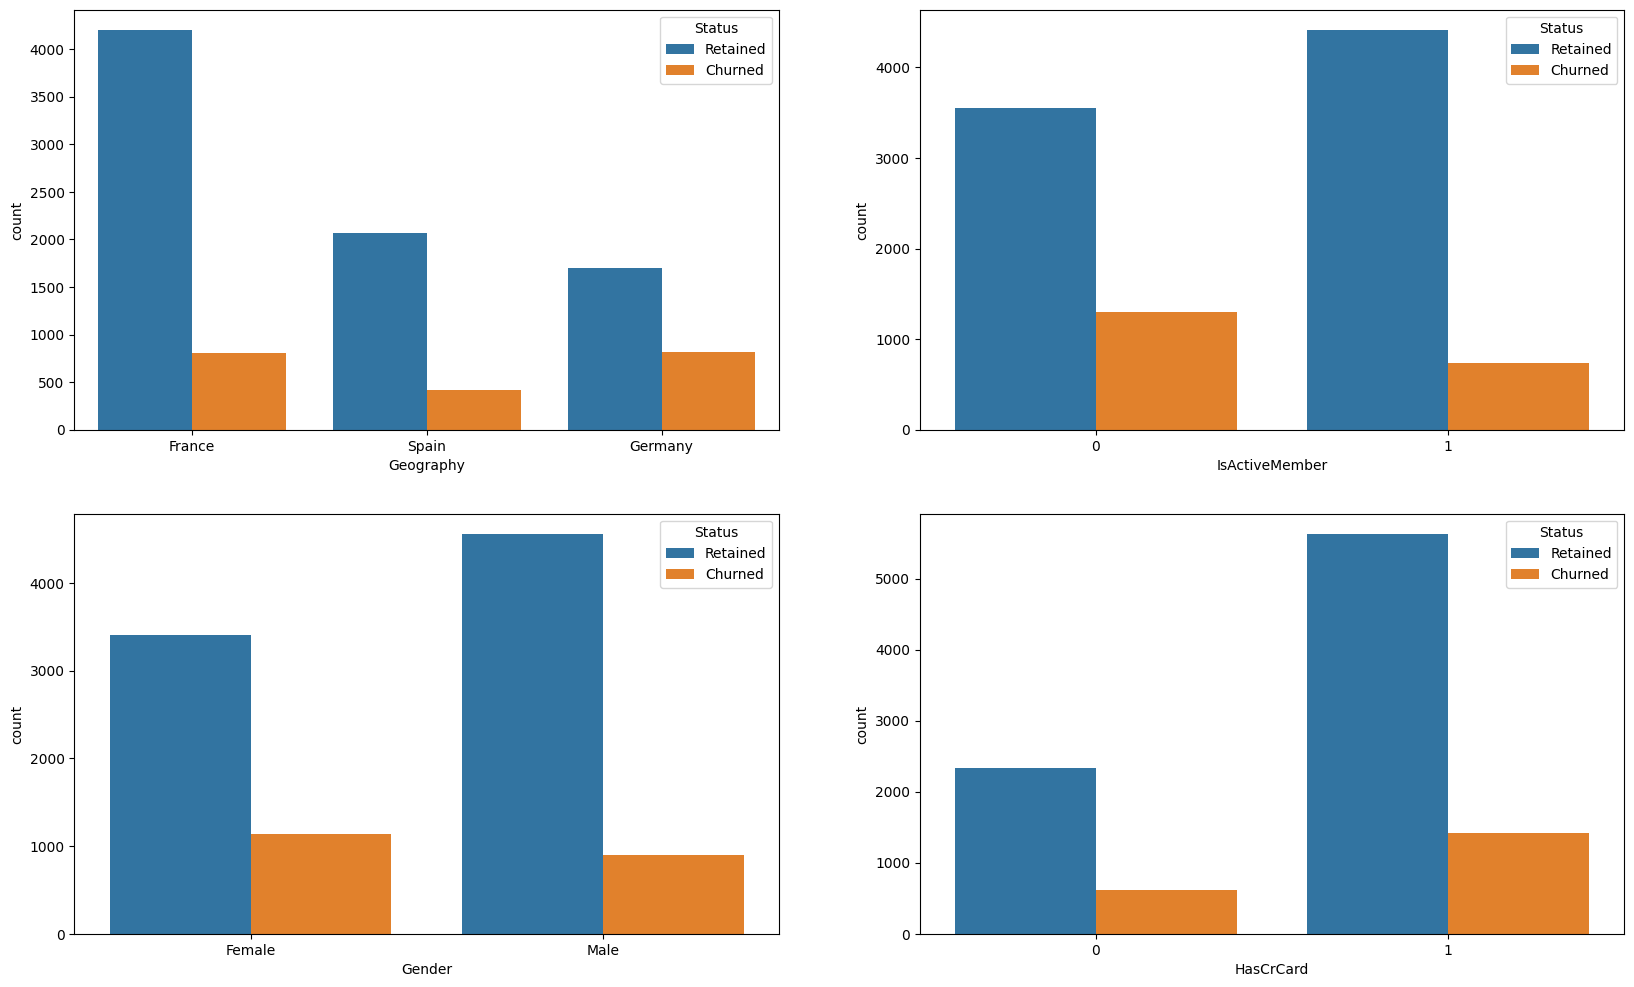

In [210]:
fig, axarr = plt.subplots(2, 2, figsize=(20,12))
sns.countplot(df_churn, x='Geography', hue="Exited_Label", hue_order=['Retained','Churned'], ax=axarr[0][0]).legend(title='Status')
sns.countplot(df_churn, x='IsActiveMember', hue='Exited_Label', hue_order=['Retained','Churned'], ax=axarr[0][1]).legend(title='Status')
sns.countplot(df_churn, x='Gender', hue='Exited_Label', hue_order=['Retained','Churned'], ax=axarr[1][0]).legend(title='Status')
sns.countplot(df_churn, x='HasCrCard', hue='Exited_Label', hue_order=['Retained','Churned'], ax=axarr[1][1]).legend(title='Status')

The charts reveal several noteworthy patterns. Having a credit card shows 
no meaningful relationship with churn, suggesting it is not a differentiating 
factor in retention. In contrast, membership activity and geography show 
clear differences between churned and retained customers.

Germany stands out as a concern — despite having fewer customers than France, 
it presents a disproportionately high churn-to-customer ratio, suggesting the 
bank may need to revisit its approach to customer needs in that market.

Inactive members show a significantly higher churn rate than active ones. 
Since inactive members represent a substantial portion of the total customer 
base, developing a re-engagement programme to convert this group into active 
members should be a priority — with a direct positive impact on overall retention.

Gender also shows a relevant pattern: although female customers represent a 
smaller share of the total base, they churn at a higher rate than male customers 
— a segment worth targeting in future retention strategies.

### 3.3 Age Group Analysis

Age was identified as a significant risk factor during the SQL exploratory 
analysis, with mature clients (45+) showing a churn rate of 44.28% — more 
than double that of young adults (18–32) at 7.62%.

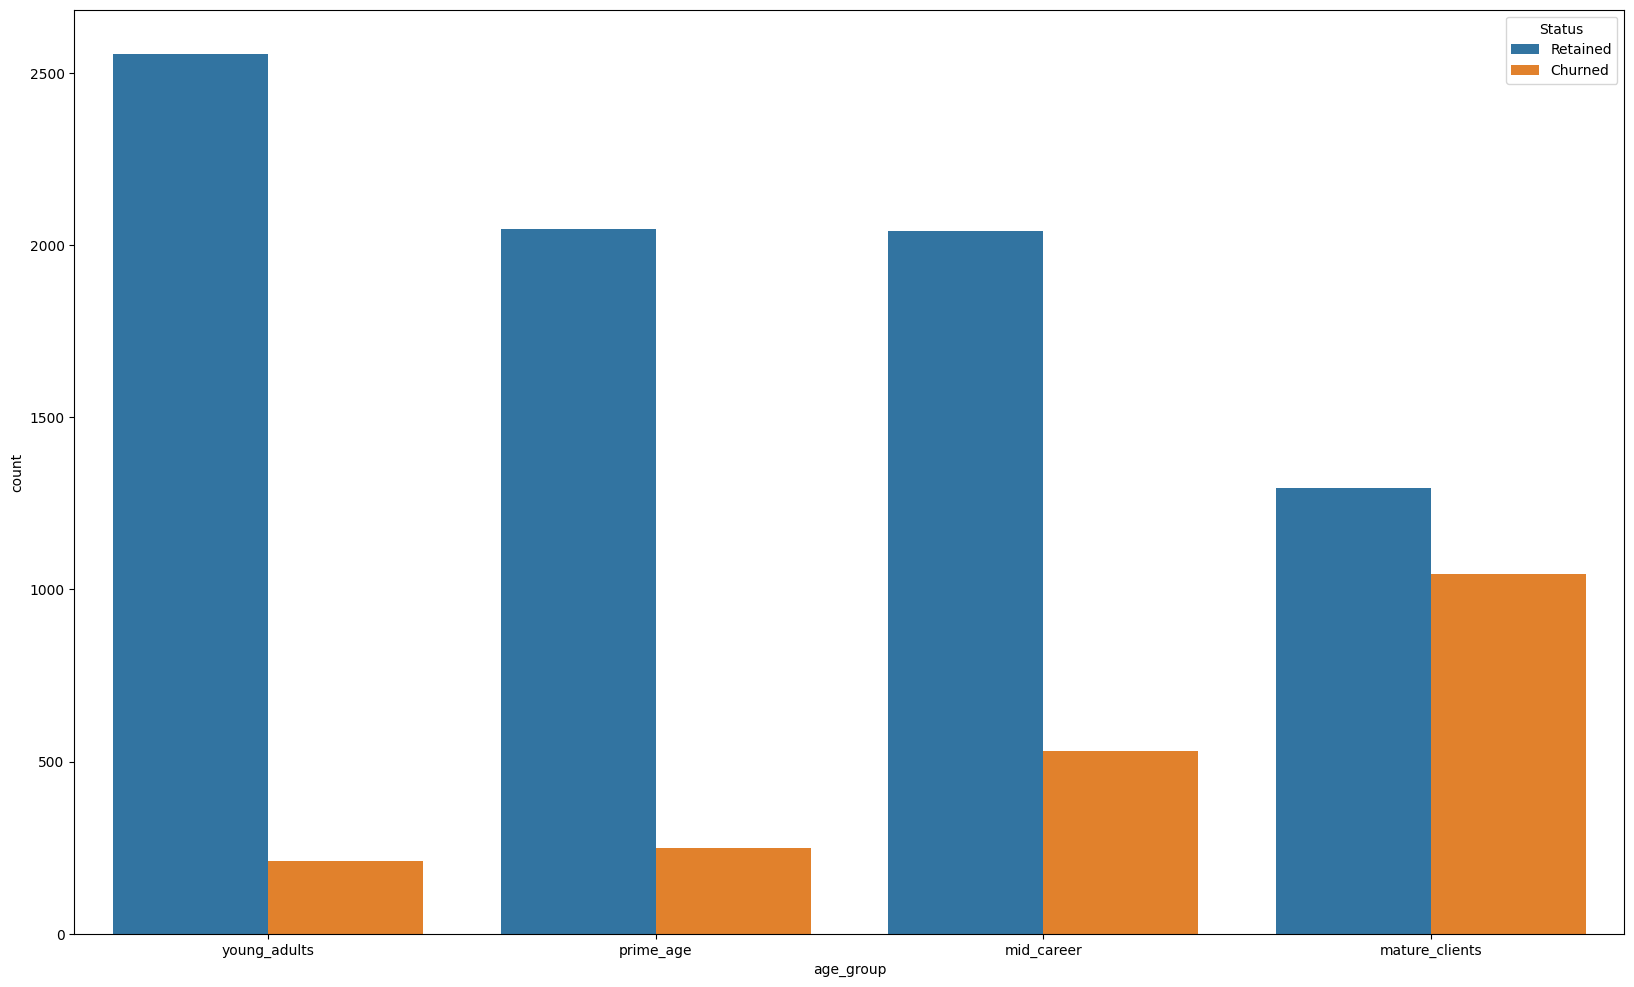

In [211]:
# Dividing the age groups to get a better perspective 
fig, ax = plt.subplots (1, 1, figsize=(20,12))
df_churn['age_group'] = pd.cut(
    df_churn['Age'],
    bins=[18,32,37,44,92],
    labels=['young_adults','prime_age','mid_career','mature_clients']
)
sns.countplot(df_churn, x='age_group', hue= 'Exited_Label', hue_order=['Retained','Churned']).legend(title='Status')

The charts confirm a strong relationship between age and churn. As age 
increases, the total number of customers decreases while the churn rate 
rises significantly. This pattern suggests meaningful differences in service 
preferences across age groups. The bank should consider reviewing its 
product offerings and communication strategies to better address the needs 
of older customers — its highest-risk segment.

### 3.4 Continuous Variable Analysis

The boxplots below compare the distribution of continuous variables between 
churned and retained customers.

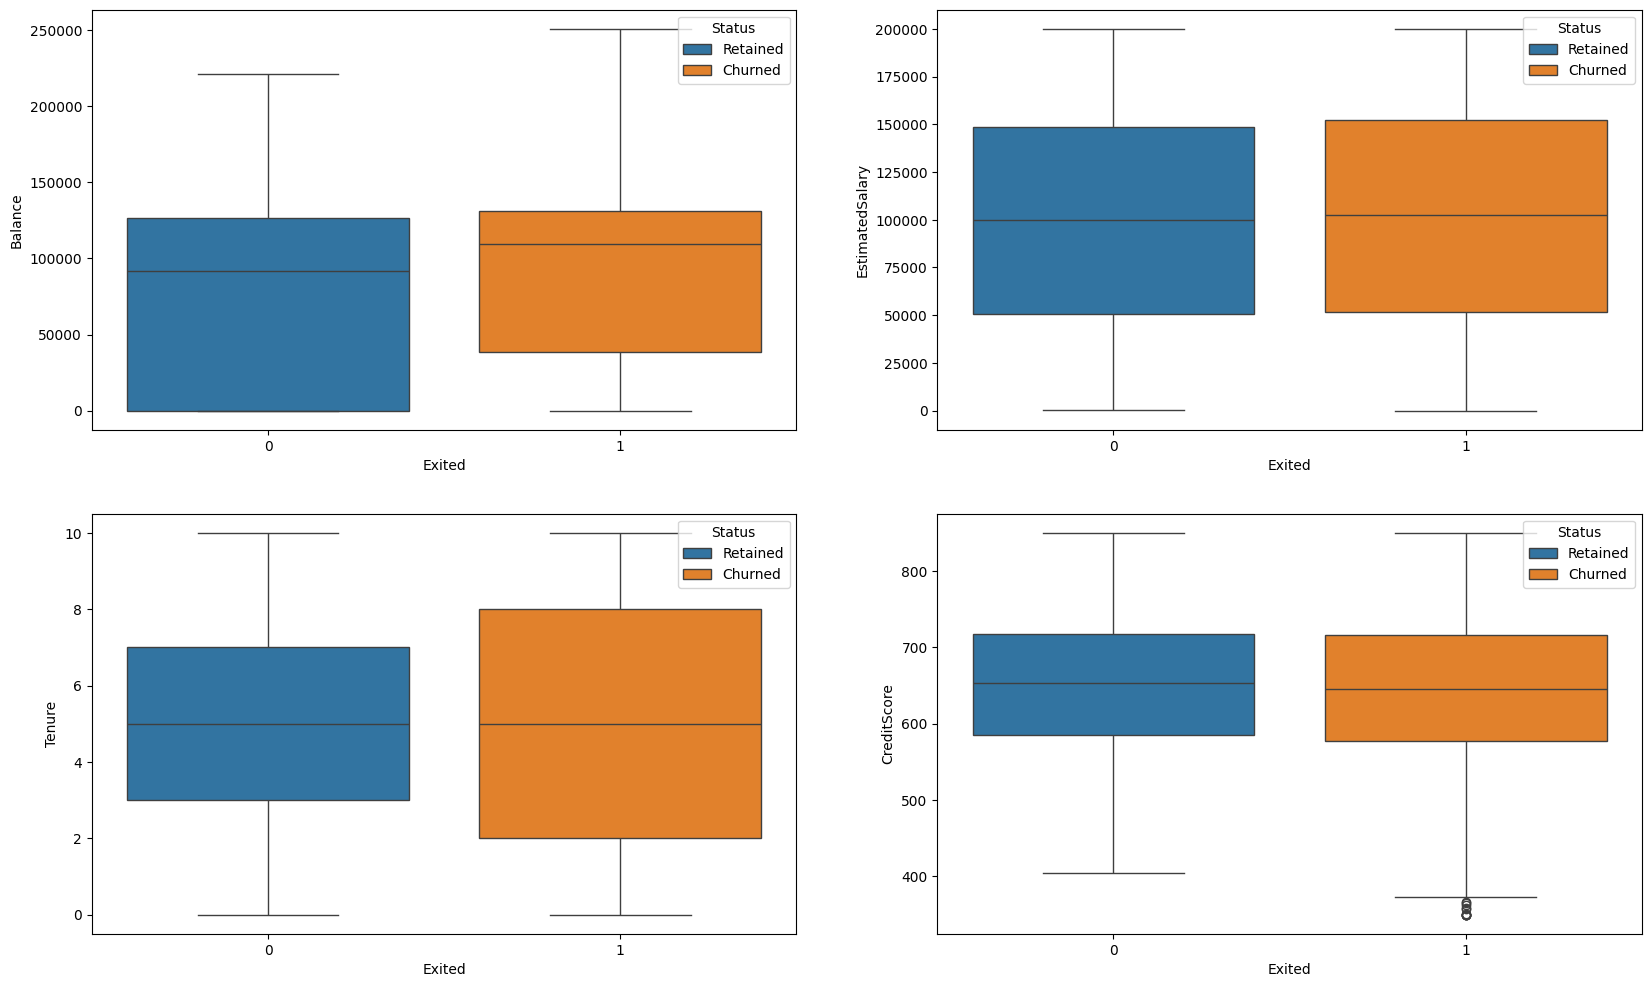

In [212]:
 # Relations based on the continuous data attributes
fig, axarr = plt.subplots(2,2, figsize=(20,12))
sns.boxplot(df_churn, x='Exited',y='Balance',hue='Exited_Label',ax=axarr[0][0]).legend(title='Status', loc='upper right')
sns.boxplot(df_churn, x='Exited', y='EstimatedSalary', hue='Exited_Label', ax=axarr[0][1]).legend(title='Status', loc='upper right')
sns.boxplot(df_churn, x='Exited', y='Tenure', hue='Exited_Label', ax=axarr[1][0]).legend(title='Status', loc='upper right')
sns.boxplot(df_churn, x='Exited', y='CreditScore', hue='Exited_Label', ax=axarr[1][1]).legend(title='Status', loc='upper right')

Estimated salary and credit score show no meaningful difference between 
churned and retained customers, indicating they are not reliable churn predictors.

Tenure reveals an interesting pattern — customers at both extremes (very new 
and very long-tenured) are more likely to churn than those with average tenure, 
suggesting the bank struggles with both early retention and long-term loyalty.

Balance is the most telling variable: churned customers tend to carry higher 
balances than retained ones, meaning the bank is losing its most financially 
valuable customers — a significant revenue risk.

## 4. Conclusions & Recommendations

With an overall churn rate of 20.37% — well above the healthy industry 
benchmark of 5–7% — this bank faces a serious retention problem that 
is disproportionately affecting its most valuable customers.

### Key risk profile
The data points to a clear high-risk customer: **an older, female, German 
customer with a high balance and low activity**. This is not a fringe case 
— these characteristics cluster together and represent a significant share 
of the churned base.

### What this costs the bank
Losing high-balance customers is not just a retention metric — it directly 
reduces the capital available for lending, which is the core revenue engine 
of any bank. A 20% churn rate sustained over several years can materially 
erode the deposit base and force the bank to seek more expensive funding sources.

### Recommended actions

**1. Launch a Germany-specific investigation**
A 32.44% churn rate in one market is an operational red flag, not a 
statistical anomaly. The bank should conduct exit interviews, compare 
product competitiveness against local rivals, and audit its customer 
service quality in that region before launching any retention campaign.

**2. Build an inactive member re-engagement programme**
Inactive members are a leading indicator of churn — they haven't left 
yet, but they're disengaged. A targeted programme offering personalised 
incentives, product recommendations, or outreach calls could convert a 
significant portion before they exit.

**3. Redesign the value proposition for mature clients**
Customers aged 45+ churn at 44.28%. This age group typically has the 
highest balances and the greatest financial needs — mortgages, retirement 
planning, wealth management. If they are leaving, the bank's product 
offering is likely not meeting those needs. A dedicated senior segment 
strategy with tailored products and relationship managers could reverse this.

**4. Investigate the female customer experience**
Female customers churn at a higher rate despite representing a smaller 
share of the base. This warrants a dedicated audit of whether the bank's 
products, communication, and service quality are equally meeting the needs 
of female customers.

**5. Fix the tenure curve**
Churn at both ends of the tenure spectrum suggests two separate problems: 
poor onboarding for new customers, and a failure to reward loyalty for 
long-tenured ones. Structured onboarding journeys and tiered loyalty 
benefits are well-established solutions to both.